# MVP Análise de Dados e Boas Práticas

**Nome:** Rafael Theodoro Rocha

**Matrícula:** 40530010055

**Dataset:** Base analítica de **Churn de Clientes da API PIX**

**---OBSERVAÇÕES IMPORTANTES---**

Este notebook foi **revisado e refatorado** com foco em boas práticas de análise de dados, coerência de comentários, padronização de escrita e domínio de negócio de **API/Pagamentos PIX**. Como não há um arquivo de dados bruto anexado junto ao template original, a etapa de carga foi ajustada para:

- utilizar automaticamente um arquivo local, caso ele exista no ambiente;
- e, na ausência de arquivo, gerar uma **base sintética controlada** com estrutura compatível ao problema de churn, apenas para viabilizar a execução completa do notebook.

O objetivo deste material é estruturar a análise exploratória, os diagnósticos de qualidade, os insights de negócio e um pipeline de pré-processamento, **sem incluir modelo de Machine Learning**, conforme solicitado.


# Descrição do Problema

No contexto de produtos financeiros baseados em **API PIX**, a retenção de clientes é um ponto crítico para a sustentabilidade da receita e para o crescimento da operação. O problema de negócio consiste em identificar padrões comportamentais, operacionais e financeiros associados ao **churn de clientes**, isto é, clientes que reduziram drasticamente o uso da API, encerraram o relacionamento comercial ou deixaram de transacionar em um período relevante.

Sob a ótica analítica, este notebook busca examinar atributos como volume transacional, valor movimentado, frequência de uso, estabilidade operacional, incidência de falhas, tempo de relacionamento e nível de engajamento com o produto. A partir dessa leitura, pretende-se entender quais variáveis sinalizam maior risco de evasão e quais evidências podem apoiar ações preventivas das áreas de produto, atendimento, operações e sucesso do cliente.


## Hipóteses do Problema

As hipóteses de análise consideradas para o problema de churn em clientes da API PIX são as seguintes:

1. **Clientes com menor volume de transações e menor recorrência de uso apresentam maior propensão ao churn.**

2. **Clientes com maior taxa de erro, maior instabilidade operacional ou maior volume de falhas tendem a abandonar a solução com mais frequência.**

3. **Clientes com menor tempo de relacionamento e menor diversificação de uso da API tendem a apresentar risco de churn mais elevado quando comparados aos clientes mais maduros e recorrentes.**


## Tipo de Problema

Este problema é tratado como um caso de **classificação supervisionada binária**, no qual o objetivo futuro será classificar cada cliente entre as classes **permanece ativo** e **churn**. Entretanto, neste notebook o foco está restrito às etapas de **entendimento do problema, análise exploratória, qualidade de dados e pré-processamento**, sem aplicação de modelos de Machine Learning.

Do ponto de vista de negócio, também se trata de um problema de **retenção e prevenção de perda de receita**, pois a saída de um cliente da API PIX pode impactar transações, faturamento, relacionamento comercial e previsibilidade operacional.


## Seleção de Dados

Para analisar churn no contexto de API PIX, a seleção de dados deve priorizar atributos que representem:

- **perfil do cliente**, como segmento, porte e tempo de relacionamento;
- **uso da API**, como quantidade de transações, frequência e recorrência;
- **desempenho operacional**, como taxa de sucesso, falhas e indisponibilidades;
- **valor financeiro**, como ticket médio e valor total transacionado;
- **engajamento**, como dias desde a última transação e concentração de uso.

Neste notebook, a base utilizada possui granularidade em nível de **cliente**, permitindo observar o comportamento agregado e identificar sinais de redução de uso ou abandono. Essa estrutura é adequada para análises descritivas, diagnósticos de consistência e preparação dos dados para uma etapa posterior de modelagem.


## Atributos do Dataset

A base analítica foi estruturada com atributos aderentes ao contexto de churn em clientes da API PIX. Os principais campos utilizados são:

- ***id_cliente***: identificador único do cliente;
- ***segmento***: classificação do cliente no negócio (por exemplo: PME, Enterprise, Startup);
- ***uf***: unidade federativa predominante de operação;
- ***tempo_base_meses***: tempo de relacionamento do cliente com a operação, em meses;
- ***transacoes_30d***: quantidade de transações PIX realizadas nos últimos 30 dias;
- ***valor_total_30d***: valor financeiro total movimentado nos últimos 30 dias;
- ***ticket_medio_30d***: valor médio por transação no período;
- ***dias_desde_ultima_transacao***: número de dias desde a última transação registrada;
- ***taxa_erro_30d***: proporção de transações com erro nos últimos 30 dias;
- ***qtd_falhas_30d***: quantidade absoluta de falhas operacionais no período;
- ***percentual_pix_noturno***: participação das transações ocorridas em janela noturna;
- ***concentracao_top_dia***: grau de concentração do volume no dia de maior movimento;
- ***possui_webhook***: indicador de adoção de integração complementar;
- ***status_cliente***: situação atual do cliente no relacionamento;
- ***churn***: variável-alvo binária que indica ocorrência ou não de churn.

**Observação de revisão:** os atributos foram reescritos para refletir o domínio de negócio de **API PIX** e manter coerência com as etapas analíticas do notebook.


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção foi **revisada** para consolidar todas as bibliotecas utilizadas ao longo do notebook em uma única célula de importação, conforme boa prática de organização. Também foi incluída uma rotina robusta de carga de dados para leitura automática de arquivo local, com geração de base sintética de apoio caso nenhum arquivo esteja disponível no ambiente.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
# Carga do dataset:
# 1) tenta localizar um arquivo local compatível;
# 2) se não encontrar, gera uma base sintética para manter o notebook executável.

def gerar_base_sintetica_churn_api_pix(n_clientes: int = 800, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    segmentos = np.array(["PME", "Enterprise", "Startup", "Marketplace"])
    ufs = np.array(["SP", "RJ", "MG", "PR", "SC", "RS", "GO", "BA", "PE", "DF"])
    status = np.array(["ativo", "em_risco", "inativo"])

    df_sint = pd.DataFrame({
        "id_cliente": np.arange(100000, 100000 + n_clientes),
        "segmento": rng.choice(segmentos, size=n_clientes, p=[0.45, 0.20, 0.20, 0.15]),
        "uf": rng.choice(ufs, size=n_clientes),
        "tempo_base_meses": rng.integers(1, 49, size=n_clientes),
        "transacoes_30d": rng.poisson(lam=180, size=n_clientes),
        "valor_total_30d": rng.gamma(shape=2.5, scale=8500, size=n_clientes),
        "dias_desde_ultima_transacao": rng.integers(0, 61, size=n_clientes),
        "taxa_erro_30d": np.clip(rng.beta(a=1.7, b=18, size=n_clientes), 0, 1),
        "qtd_falhas_30d": rng.poisson(lam=4, size=n_clientes),
        "percentual_pix_noturno": np.clip(rng.beta(a=2.2, b=5.5, size=n_clientes), 0, 1),
        "concentracao_top_dia": np.clip(rng.beta(a=2.8, b=3.2, size=n_clientes), 0, 1),
        "possui_webhook": rng.choice(["sim", "nao"], size=n_clientes, p=[0.62, 0.38]),
        "status_cliente": rng.choice(status, size=n_clientes, p=[0.72, 0.18, 0.10]),
    })

    df_sint["ticket_medio_30d"] = np.where(
        df_sint["transacoes_30d"] > 0,
        df_sint["valor_total_30d"] / df_sint["transacoes_30d"],
        0
    )

    score_churn = (
        0.035 * df_sint["dias_desde_ultima_transacao"]
        + 12 * df_sint["taxa_erro_30d"]
        + 0.18 * df_sint["qtd_falhas_30d"]
        - 0.008 * df_sint["transacoes_30d"]
        - 0.015 * df_sint["tempo_base_meses"]
        - 0.45 * (df_sint["possui_webhook"] == "sim").astype(int)
        + 0.70 * (df_sint["status_cliente"] == "em_risco").astype(int)
        + 1.10 * (df_sint["status_cliente"] == "inativo").astype(int)
    )

    prob_churn = 1 / (1 + np.exp(-(score_churn - np.median(score_churn))))
    df_sint["churn"] = np.where(rng.random(n_clientes) < prob_churn, 1, 0)

    # Introdução controlada de alguns nulos para enriquecer a etapa de qualidade e pré-processamento
    for col in ["ticket_medio_30d", "taxa_erro_30d", "segmento"]:
        idx = rng.choice(df_sint.index, size=max(5, int(n_clientes * 0.02)), replace=False)
        df_sint.loc[idx, col] = np.nan

    return df_sint

possiveis_arquivos = (
    list(Path("/mnt/data").glob("*.csv")) +
    list(Path("/mnt/data").glob("*.xlsx")) +
    list(Path(".").glob("*.csv")) +
    list(Path(".").glob("*.xlsx"))
)

arquivo_dados = None
for arq in possiveis_arquivos:
    if "Template" not in arq.name and not arq.name.endswith(".ipynb"):
        arquivo_dados = arq
        break

if arquivo_dados is not None and arquivo_dados.suffix.lower() == ".csv":
    df = pd.read_csv(arquivo_dados)
    origem_dados = f"arquivo local CSV: {arquivo_dados.name}"
elif arquivo_dados is not None and arquivo_dados.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(arquivo_dados)
    origem_dados = f"arquivo local Excel: {arquivo_dados.name}"
else:
    df = gerar_base_sintetica_churn_api_pix()
    origem_dados = "base sintética gerada automaticamente"

print(f"Origem dos dados utilizada no notebook: {origem_dados}")


Origem dos dados utilizada no notebook: base sintética gerada automaticamente


In [3]:
# Padronização inicial dos nomes de colunas e criação de cópia analítica do dataset
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace("/", "_", regex=False)
      .str.replace("(", "", regex=False)
      .str.replace(")", "", regex=False)
)

df = df.copy()

# Garantia mínima de colunas esperadas no template analítico
if "churn" not in df.columns:
    raise ValueError("A base precisa conter a coluna 'churn' para análise do problema de retenção.")

df.head()


,id_cliente,segmento,uf,tempo_base_meses,transacoes_30d,valor_total_30d,dias_desde_ultima_transacao,taxa_erro_30d,qtd_falhas_30d,percentual_pix_noturno,concentracao_top_dia,possui_webhook,status_cliente,ticket_medio_30d,churn
0,100000,Startup,PR,1,202,"2,342.2155",35,NaN,9,0.2956,0.3890,sim,ativo,11.5951,1
1,100001,PME,BA,28,187,"20,083.7078",2,0.1355,8,0.3015,0.5142,sim,em_risco,107.3995,1
2,100002,Marketplace,PE,36,169,"7,756.4126",39,0.0564,3,0.1309,0.3477,nao,ativo,45.8959,1
3,100003,Startup,PR,27,217,"19,895.0342",26,0.0659,3,0.1629,0.7222,sim,em_risco,91.6822,0
4,100004,PME,RJ,19,177,"20,179.2038",7,0.1377,2,0.2491,0.6910,nao,ativo,114.0068,0


In [4]:
# Visualização inicial da base para validação estrutural
df.head(10)


,id_cliente,segmento,uf,tempo_base_meses,transacoes_30d,valor_total_30d,dias_desde_ultima_transacao,taxa_erro_30d,qtd_falhas_30d,percentual_pix_noturno,concentracao_top_dia,possui_webhook,status_cliente,ticket_medio_30d,churn
0,100000,Startup,PR,1,202,"2,342.2155",35,NaN,9,0.2956,0.3890,sim,ativo,11.5951,1
1,100001,PME,BA,28,187,"20,083.7078",2,0.1355,8,0.3015,0.5142,sim,em_risco,107.3995,1
2,100002,Marketplace,PE,36,169,"7,756.4126",39,0.0564,3,0.1309,0.3477,nao,ativo,45.8959,1
3,100003,Startup,PR,27,217,"19,895.0342",26,0.0659,3,0.1629,0.7222,sim,em_risco,91.6822,0
4,100004,PME,RJ,19,177,"20,179.2038",7,0.1377,2,0.2491,0.6910,nao,ativo,114.0068,0
5,100005,Marketplace,PE,40,170,"18,516.8664",13,0.0092,6,0.1229,0.5375,nao,ativo,108.9227,0
6,100006,Startup,RJ,18,191,"35,200.3175",47,0.0285,3,0.2728,0.6742,sim,ativo,184.2949,0
7,100007,Startup,RS,35,195,"80,841.2626",55,0.0801,5,0.2194,0.6630,sim,em_risco,414.5706,1
8,100008,PME,MG,23,167,"23,604.2069",30,0.0485,2,0.3047,0.3465,sim,ativo,141.3426,0
9,100009,Enterprise,RJ,2,193,"53,301.0552",59,0.0735,3,0.3104,0.3108,nao,em_risco,276.1713,1


# Análise de Dados

Nesta etapa de **Análise Exploratória de Dados (EDA)**, o objetivo é compreender a estrutura da base, a qualidade das informações, a distribuição dos atributos e os sinais de negócio associados ao churn de clientes da API PIX.

**Observação de revisão:** foram ajustadas células incompletas, comentários vagos e trechos inconsistentes, com inclusão de interpretações analíticas e padronização da linguagem ao longo do notebook.


## Total e Tipo das Instâncias

Nesta etapa, avaliamos o tamanho da base, os tipos de dados e a composição geral das variáveis. Essa leitura é importante para identificar:

- volume de observações disponível para análise;
- campos numéricos e categóricos;
- necessidade de conversão de tipos;
- possíveis inconsistências estruturais antes do pré-processamento.


In [5]:
print(f"Total de instâncias: {len(df)}")
print(f"Total de colunas: {df.shape[1]}")
print("\nTipos de dados por coluna:")
display(df.dtypes.to_frame("dtype"))

print("\nResumo estrutural do dataset:")
df.info()


Total de instâncias: 800
Total de colunas: 15

Tipos de dados por coluna:


,dtype
id_cliente,int64
segmento,object
uf,object
tempo_base_meses,int64
transacoes_30d,int64
valor_total_30d,float64
dias_desde_ultima_transacao,int64
taxa_erro_30d,float64
qtd_falhas_30d,int64
percentual_pix_noturno,float64



Resumo estrutural do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_cliente                   800 non-null    int64  
 1   segmento                     784 non-null    object 
 2   uf                           800 non-null    object 
 3   tempo_base_meses             800 non-null    int64  
 4   transacoes_30d               800 non-null    int64  
 5   valor_total_30d              800 non-null    float64
 6   dias_desde_ultima_transacao  800 non-null    int64  
 7   taxa_erro_30d                784 non-null    float64
 8   qtd_falhas_30d               800 non-null    int64  
 9   percentual_pix_noturno       800 non-null    float64
 10  concentracao_top_dia         800 non-null    float64
 11  possui_webhook               800 non-null    object 
 12  status_cliente               800 non-null    ob

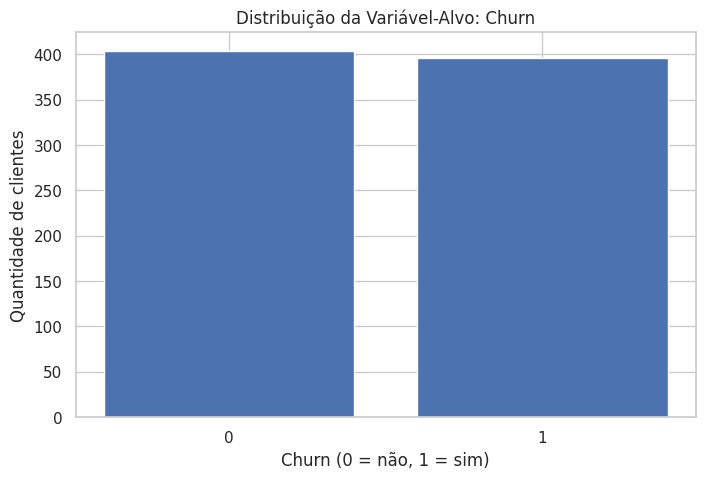

In [6]:
distribuicao_churn = df["churn"].astype(str).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(distribuicao_churn.index, distribuicao_churn.values)
plt.title("Distribuição da Variável-Alvo: Churn")
plt.xlabel("Churn (0 = não, 1 = sim)")
plt.ylabel("Quantidade de clientes")
plt.show()


O gráfico de barras mostra a distribuição da variável-alvo **churn**. Essa visualização é importante para verificar se a base está balanceada ou se existe desbalanceamento entre clientes retidos e clientes perdidos.

Em cenários reais de API PIX, bases de churn frequentemente apresentam maior volume de clientes ativos do que clientes evadidos. Caso exista desequilíbrio relevante, essa condição deve ser considerada nas próximas etapas analíticas e, futuramente, na modelagem.


## Estatísticas Descritivas

As estatísticas descritivas resumem o comportamento dos atributos numéricos e ajudam a responder perguntas como:

- qual é o volume típico de transações por cliente;
- quais variáveis apresentam maior dispersão;
- se existem amplitudes elevadas que podem indicar assimetria ou outliers;
- quais atributos merecem aprofundamento visual na EDA.


In [7]:
# Estatísticas descritivas dos atributos numéricos
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
id_cliente,800.0000,"100,399.5000",231.0844,"100,000.0000","100,199.7500","100,399.5000","100,599.2500","100,799.0000"
tempo_base_meses,800.0000,24.5437,13.8033,1.0000,12.0000,24.0000,37.0000,48.0000
transacoes_30d,800.0000,179.8675,13.1700,140.0000,171.0000,180.0000,188.2500,226.0000
valor_total_30d,800.0000,"21,397.9399","13,319.1010",517.8951,"11,474.6813","18,762.9019","27,358.9928","97,143.5378"
dias_desde_ultima_transacao,800.0000,29.1250,17.6485,0.0000,14.0000,28.0000,45.0000,60.0000
taxa_erro_30d,784.0000,0.0834,0.0575,0.0017,0.0424,0.0703,0.1144,0.3778
qtd_falhas_30d,800.0000,3.9775,2.0198,0.0000,3.0000,4.0000,5.0000,12.0000
percentual_pix_noturno,800.0000,0.2794,0.1515,0.0090,0.1635,0.2668,0.3681,0.8628
concentracao_top_dia,800.0000,0.4719,0.1866,0.0191,0.3385,0.4637,0.6124,0.9257
ticket_medio_30d,784.0000,119.8891,75.5242,2.8146,65.9581,105.5165,153.1663,542.7013


### Média

A média ajuda a entender o valor central dos atributos numéricos. No contexto de churn em API PIX, ela permite observar, por exemplo, o volume médio de transações, o ticket médio e o intervalo médio desde a última transação.

Como complemento à tabela, é útil visualizar a média dos principais indicadores para facilitar a comparação entre escalas e tornar a leitura executiva mais objetiva.


In [8]:
# Média dos atributos numéricos
medias = df.select_dtypes(include=[np.number]).mean(numeric_only=True).sort_values(ascending=False)
medias.to_frame("media")


,media
id_cliente,"100,399.5000"
valor_total_30d,"21,397.9399"
transacoes_30d,179.8675
ticket_medio_30d,119.8891
dias_desde_ultima_transacao,29.1250
tempo_base_meses,24.5437
qtd_falhas_30d,3.9775
churn,0.4950
concentracao_top_dia,0.4719
percentual_pix_noturno,0.2794


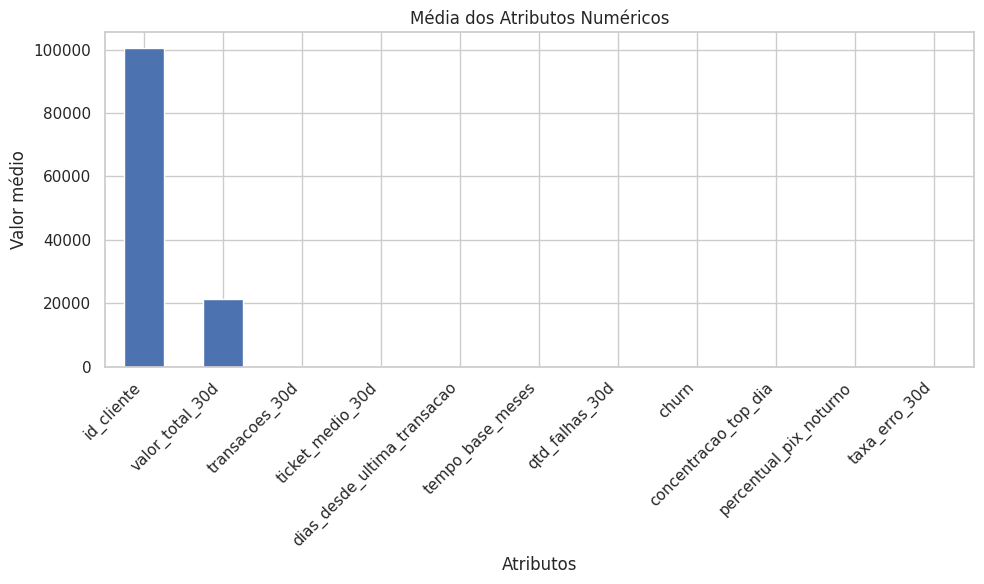

In [9]:
# Gráfico de barras com as médias dos atributos numéricos
plt.figure(figsize=(10, 6))
medias.plot(kind="bar")
plt.title("Média dos Atributos Numéricos")
plt.xlabel("Atributos")
plt.ylabel("Valor médio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Desvio Padrão

O desvio padrão mede a dispersão dos dados em relação à média. Em termos de negócio, atributos com maior variabilidade podem sinalizar comportamentos muito heterogêneos entre clientes, o que é comum em operações transacionais.

Em API PIX, é esperado que métricas como valor transacionado, quantidade de transações e dias desde a última transação apresentem dispersão relevante, pois clientes podem ter padrões de uso muito distintos.


In [10]:
# Desvio padrão dos atributos numéricos
desvios = df.select_dtypes(include=[np.number]).std(numeric_only=True).sort_values(ascending=False)
desvios.to_frame("desvio_padrao")


,desvio_padrao
valor_total_30d,"13,319.1010"
id_cliente,231.0844
ticket_medio_30d,75.5242
dias_desde_ultima_transacao,17.6485
tempo_base_meses,13.8033
transacoes_30d,13.1700
qtd_falhas_30d,2.0198
churn,0.5003
concentracao_top_dia,0.1866
percentual_pix_noturno,0.1515


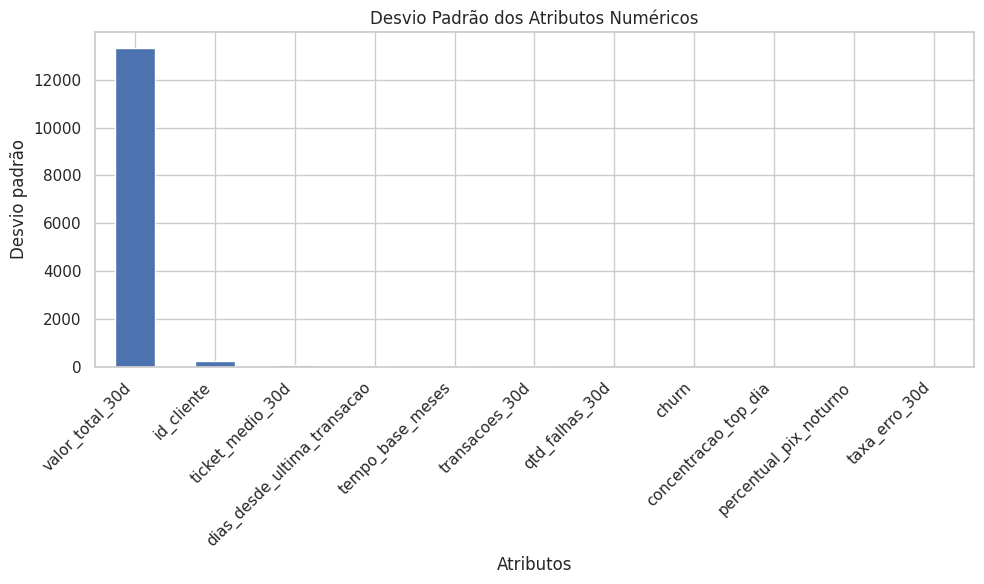

In [11]:
# Gráfico de barras com o desvio padrão dos atributos numéricos
plt.figure(figsize=(10, 6))
desvios.plot(kind="bar")
plt.title("Desvio Padrão dos Atributos Numéricos")
plt.xlabel("Atributos")
plt.ylabel("Desvio padrão")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Histograma

A análise de distribuição permite entender concentração, caudas, assimetria e possíveis agrupamentos naturais dos dados. Em bases de churn, esse tipo de leitura ajuda a identificar clientes de baixo uso, clientes muito concentrados em determinados comportamentos e variáveis com perfil potencialmente discriminante.


### *transacoes_30d*

Este atributo representa a quantidade de transações PIX realizadas pelo cliente nos últimos 30 dias. Ele é um dos principais indicadores de engajamento com a API, pois clientes com uso recorrente tendem a apresentar menor risco de evasão.


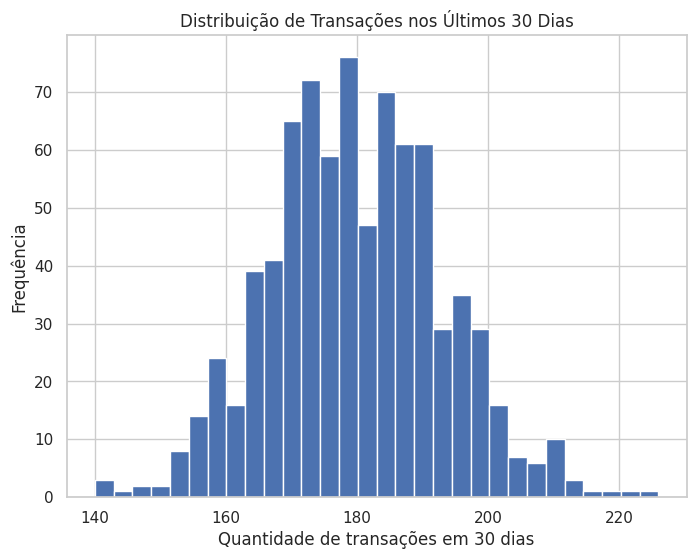

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(df["transacoes_30d"].dropna(), bins=30)
plt.title("Distribuição de Transações nos Últimos 30 Dias")
plt.xlabel("Quantidade de transações em 30 dias")
plt.ylabel("Frequência")
plt.show()


O histograma mostra como o volume transacional está distribuído na base. Em cenários de churn, é comum observar concentração em faixas menores de uso e uma cauda à direita com clientes de maior atividade.

Caso exista um grupo de clientes com transações muito baixas ou próximas de zero, esse comportamento pode indicar uma população com maior risco de abandono ou já em processo de desativação.


### *dias_desde_ultima_transacao*

Este atributo mede o tempo decorrido desde a última transação do cliente. Em negócios transacionais, costuma ser uma das variáveis mais relevantes para detectar perda de recorrência e enfraquecimento do relacionamento.


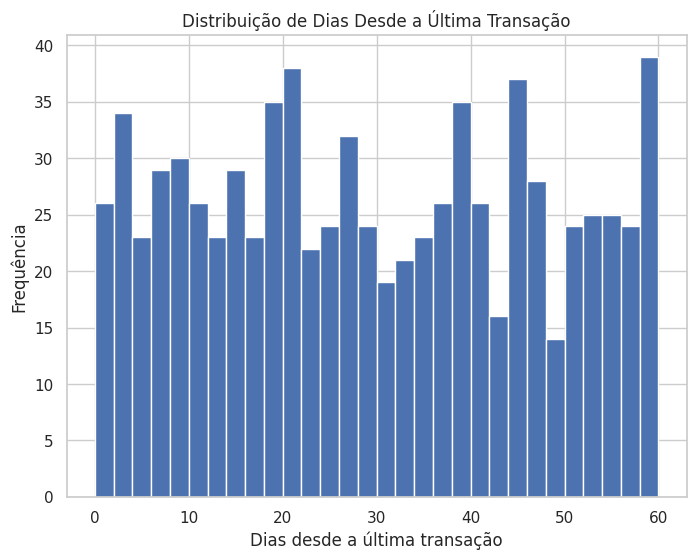

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(df["dias_desde_ultima_transacao"].dropna(), bins=30)
plt.title("Distribuição de Dias Desde a Última Transação")
plt.xlabel("Dias desde a última transação")
plt.ylabel("Frequência")
plt.show()


A distribuição de **dias_desde_ultima_transacao** ajuda a identificar clientes recentes, recorrentes e clientes possivelmente inativos. Valores mais altos merecem atenção, pois podem indicar queda de uso, pausa operacional ou churn efetivo.

**Observação de revisão:** esta interpretação foi incluída para substituir comentário aberto e tornar a análise mais objetiva e acionável.


## Boxplot

O boxplot permite comparar a distribuição dos atributos numéricos entre os grupos da variável-alvo. Essa visualização é especialmente útil para verificar separação entre clientes com e sem churn, além de evidenciar dispersão, mediana e possíveis outliers.


In [14]:
# Estatísticas descritivas agrupadas por churn
df.groupby("churn").describe(include="all").transpose()


churn                              0            1
id_cliente       count      404.0000     396.0000
                 unique          NaN          NaN
                 top             NaN          NaN
                 freq            NaN          NaN
                 mean   100,409.9653 100,388.8232
...                              ...          ...
ticket_medio_30d min          6.4030       2.8146
                 25%         62.6369      67.4412
                 50%        102.3305     107.1052
                 75%        153.5836     150.9919
                 max        424.7986     542.7013

[154 rows x 2 columns]

### *valor_total_30d* por Churn


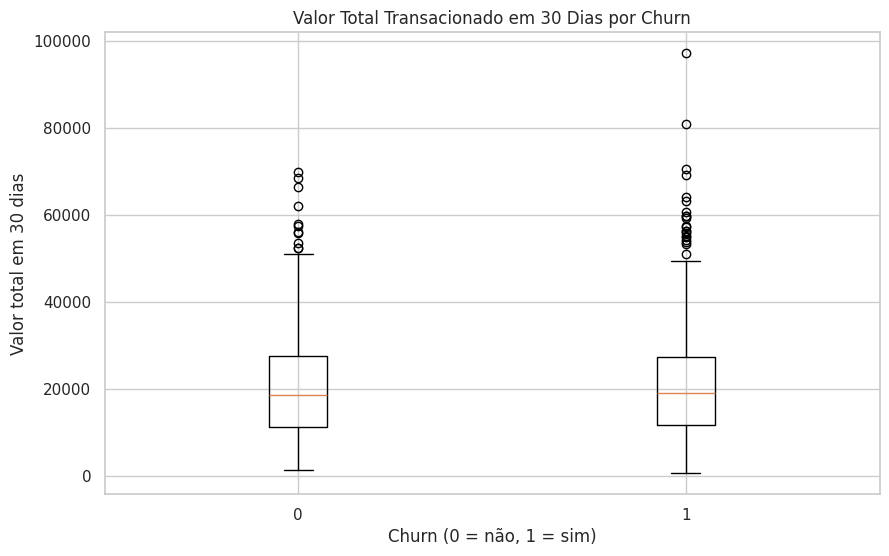

In [15]:
dados_box_34 = [
    df.loc[df["churn"] == 0, "valor_total_30d"].dropna(),
    df.loc[df["churn"] == 1, "valor_total_30d"].dropna()
]

plt.figure(figsize=(10, 6))
plt.boxplot(dados_box_34, tick_labels=["0", "1"])
plt.title("Valor Total Transacionado em 30 Dias por Churn")
plt.xlabel("Churn (0 = não, 1 = sim)")
plt.ylabel("Valor total em 30 dias")
plt.show()


O boxplot de **valor_total_30d** por churn permite verificar se clientes que saíram apresentam menor movimentação financeira quando comparados aos clientes retidos.

Quando há diferença consistente entre medianas e distribuição dos grupos, esse atributo passa a ser um forte candidato a variável explicativa do risco de churn.


### *taxa_erro_30d* por Churn


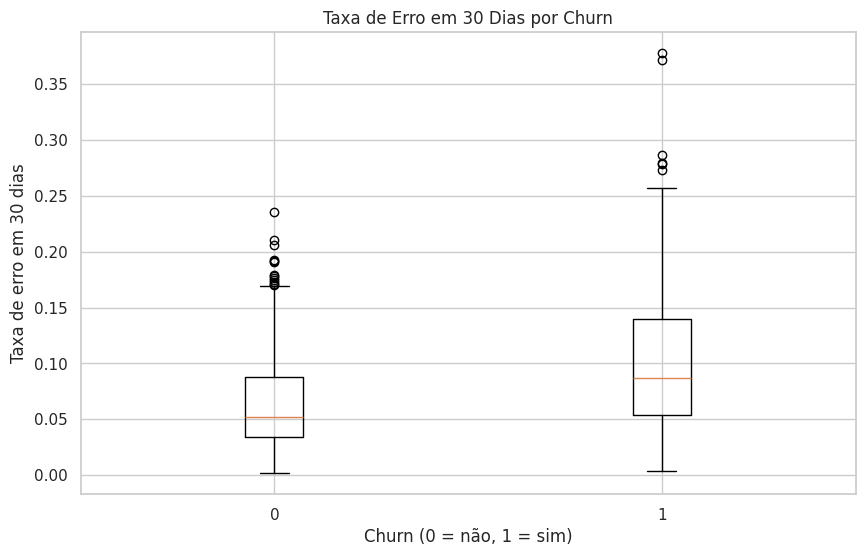

In [16]:
dados_box_37 = [
    df.loc[df["churn"] == 0, "taxa_erro_30d"].dropna(),
    df.loc[df["churn"] == 1, "taxa_erro_30d"].dropna()
]

plt.figure(figsize=(10, 6))
plt.boxplot(dados_box_37, tick_labels=["0", "1"])
plt.title("Taxa de Erro em 30 Dias por Churn")
plt.xlabel("Churn (0 = não, 1 = sim)")
plt.ylabel("Taxa de erro em 30 dias")
plt.show()


A comparação de **taxa_erro_30d** por churn ajuda a avaliar se a experiência operacional do cliente está associada à evasão. Em APIs financeiras, aumentos de falha, rejeição ou indisponibilidade tendem a impactar confiança, integração e continuidade de uso.

**Observação de revisão:** esta célula foi complementada para substituir texto incompleto e registrar uma interpretação de negócio mais precisa.


## Matriz de Correlação

A matriz de correlação mede a força e a direção da relação linear entre os atributos numéricos. Essa análise ajuda a identificar:

- variáveis com comportamento redundante;
- possíveis dependências entre volume, valor e frequência;
- candidatos a seleção de atributos em etapas futuras;
- relações coerentes com as hipóteses de churn.


In [17]:
# Matriz de correlação dos atributos numéricos
corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)
print("\nMatriz de Correlação:")
corr



Matriz de Correlação:


,id_cliente,tempo_base_meses,transacoes_30d,valor_total_30d,dias_desde_ultima_transacao,taxa_erro_30d,qtd_falhas_30d,percentual_pix_noturno,concentracao_top_dia,ticket_medio_30d,churn
id_cliente,1.0000,0.0243,-0.0409,-0.0600,-0.0276,0.0013,-0.0056,0.0099,-0.0088,-0.0441,-0.0458
tempo_base_meses,0.0243,1.0000,0.0270,-0.0240,0.0287,-0.0158,-0.0086,-0.0025,0.0088,-0.0221,-0.0943
transacoes_30d,-0.0409,0.0270,1.0000,-0.0004,0.0098,-0.0333,0.0001,0.0144,-0.0511,-0.1224,-0.0732
valor_total_30d,-0.0600,-0.0240,-0.0004,1.0000,-0.0013,0.0169,-0.0046,0.0338,-0.0475,0.9904,0.0349
dias_desde_ultima_transacao,-0.0276,0.0287,0.0098,-0.0013,1.0000,0.0106,0.0287,0.0457,0.0285,-0.0104,0.2657
taxa_erro_30d,0.0013,-0.0158,-0.0333,0.0169,0.0106,1.0000,-0.0002,-0.0245,-0.0650,0.0124,0.3093
qtd_falhas_30d,-0.0056,-0.0086,0.0001,-0.0046,0.0287,-0.0002,1.0000,0.0235,0.0997,0.0005,0.1398
percentual_pix_noturno,0.0099,-0.0025,0.0144,0.0338,0.0457,-0.0245,0.0235,1.0000,0.0373,0.0366,0.0039
concentracao_top_dia,-0.0088,0.0088,-0.0511,-0.0475,0.0285,-0.0650,0.0997,0.0373,1.0000,-0.0396,-0.0652
ticket_medio_30d,-0.0441,-0.0221,-0.1224,0.9904,-0.0104,0.0124,0.0005,0.0366,-0.0396,1.0000,0.0303


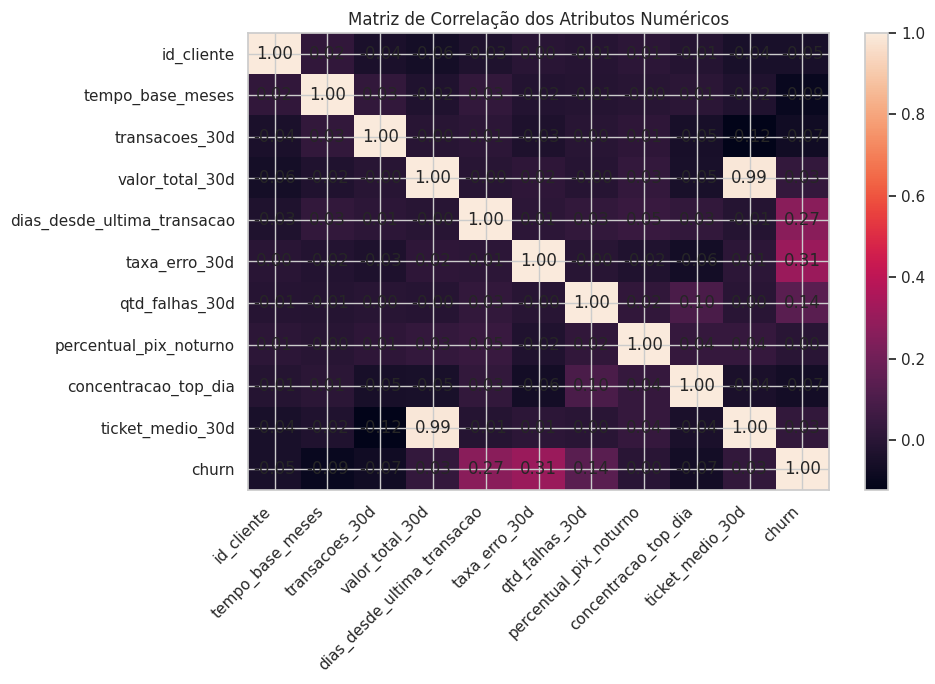

In [18]:
plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de Correlação dos Atributos Numéricos")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()


O mapa de calor permite identificar relações importantes entre os atributos numéricos. Em uma base de API PIX, é natural observar correlação positiva entre **transacoes_30d**, **valor_total_30d** e **ticket_medio_30d**, bem como relação entre sinais de queda de uso e churn.

Correlação elevada não implica causalidade, mas ajuda a orientar hipóteses, priorização analítica e decisões de pré-processamento.


## Tratamento de Valores Nulos

Antes de qualquer pipeline analítico, é essencial verificar a existência de valores ausentes. Mesmo quando a base parece íntegra, campos nulos podem surgir por falhas de integração, indisponibilidade de captura, regras de negócio ou ausência legítima de informação.


In [19]:
# Verificação de valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_percentual = (df.isnull().mean() * 100).sort_values(ascending=False)

pd.DataFrame({
    "qtd_nulos": nulos,
    "percentual_nulos": nulos_percentual
})


,qtd_nulos,percentual_nulos
segmento,16,2.0000
ticket_medio_30d,16,2.0000
taxa_erro_30d,16,2.0000
tempo_base_meses,0,0.0000
transacoes_30d,0,0.0000
id_cliente,0,0.0000
uf,0,0.0000
dias_desde_ultima_transacao,0,0.0000
valor_total_30d,0,0.0000
percentual_pix_noturno,0,0.0000


# Pré-Processamento de Dados

O pré-processamento foi **revisado e reorganizado** para refletir as evidências levantadas na análise exploratória. Como o foco deste notebook não é modelagem, a proposta abaixo prioriza um pipeline limpo, reprodutível e aderente ao problema de churn em clientes da API PIX.


In [20]:
# Separação entre variáveis explicativas e variável-alvo
X = df.drop(columns=["churn"])
y = df["churn"]

print(f"Dimensão de X: {X.shape}")
print(f"Dimensão de y: {y.shape}")


Dimensão de X: (800, 14)
Dimensão de y: (800,)


In [21]:
# Identificação automática dos grupos de variáveis
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("Colunas categóricas:", colunas_categoricas)


Colunas numéricas: ['id_cliente', 'tempo_base_meses', 'transacoes_30d', 'valor_total_30d', 'dias_desde_ultima_transacao', 'taxa_erro_30d', 'qtd_falhas_30d', 'percentual_pix_noturno', 'concentracao_top_dia', 'ticket_medio_30d']
Colunas categóricas: ['segmento', 'uf', 'possui_webhook', 'status_cliente']


In [22]:
print(f"Quantidade de atributos numéricos: {len(colunas_numericas)}")
print(f"Quantidade de atributos categóricos: {len(colunas_categoricas)}")


Quantidade de atributos numéricos: 10
Quantidade de atributos categóricos: 4


## Normalização

A normalização por **Min-Max Scaling** é indicada quando desejamos colocar atributos numéricos na mesma faixa de valores, normalmente entre 0 e 1. Isso pode ser útil em cenários futuros de modelagem e também para comparações visuais entre variáveis originalmente muito diferentes em escala.


In [23]:
# Pipeline de transformação numérica com imputação e normalização
pipeline_normalizacao = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("normalizacao", MinMaxScaler())
])

X_normalizado = pd.DataFrame(
    pipeline_normalizacao.fit_transform(X[colunas_numericas]),
    columns=colunas_numericas,
    index=X.index
)


In [24]:
# Visualização da base numérica normalizada
X_normalizado.head()


,id_cliente,tempo_base_meses,transacoes_30d,valor_total_30d,dias_desde_ultima_transacao,taxa_erro_30d,qtd_falhas_30d,percentual_pix_noturno,concentracao_top_dia,ticket_medio_30d
0,0.0000,0.0000,0.7209,0.0189,0.5833,0.1825,0.7500,0.3357,0.4080,0.0163
1,0.0013,0.5745,0.5465,0.2025,0.0333,0.3558,0.6667,0.3426,0.5461,0.1937
2,0.0025,0.7447,0.3372,0.0749,0.6500,0.1453,0.2500,0.1427,0.3625,0.0798
3,0.0038,0.5532,0.8953,0.2005,0.4333,0.1708,0.2500,0.1803,0.7755,0.1646
4,0.0050,0.3830,0.4302,0.2035,0.1167,0.3617,0.1667,0.2812,0.7411,0.2060


In [25]:
df_normalized = X_normalizado.copy()
df_normalized.describe().T


,count,mean,std,min,25%,50%,75%,max
id_cliente,800.0000,0.5000,0.2892,0.0000,0.2500,0.5000,0.7500,1.0000
tempo_base_meses,800.0000,0.5009,0.2937,0.0000,0.2340,0.4894,0.7660,1.0000
transacoes_30d,800.0000,0.4636,0.1531,0.0000,0.3605,0.4651,0.5610,1.0000
valor_total_30d,800.0000,0.2161,0.1378,0.0000,0.1134,0.1888,0.2778,1.0000
dias_desde_ultima_transacao,800.0000,0.4854,0.2941,0.0000,0.2333,0.4667,0.7500,1.0000
taxa_erro_30d,800.0000,0.2165,0.1515,0.0000,0.1104,0.1825,0.2945,1.0000
qtd_falhas_30d,800.0000,0.3315,0.1683,0.0000,0.2500,0.3333,0.4167,1.0000
percentual_pix_noturno,800.0000,0.3168,0.1775,0.0000,0.1810,0.3020,0.4206,1.0000
concentracao_top_dia,800.0000,0.4994,0.2058,0.0000,0.3523,0.4905,0.6544,1.0000
ticket_medio_30d,800.0000,0.2163,0.1385,0.0000,0.1189,0.1902,0.2766,1.0000


In [26]:
print("\nPrimeiras 5 linhas dos dados normalizados:")
print(df_normalized.head())



Primeiras 5 linhas dos dados normalizados:
   id_cliente  tempo_base_meses  transacoes_30d  valor_total_30d  \
0      0.0000            0.0000          0.7209           0.0189   
1      0.0013            0.5745          0.5465           0.2025   
2      0.0025            0.7447          0.3372           0.0749   
3      0.0038            0.5532          0.8953           0.2005   
4      0.0050            0.3830          0.4302           0.2035   

   dias_desde_ultima_transacao  taxa_erro_30d  qtd_falhas_30d  \
0                       0.5833         0.1825          0.7500   
1                       0.0333         0.3558          0.6667   
2                       0.6500         0.1453          0.2500   
3                       0.4333         0.1708          0.2500   
4                       0.1167         0.3617          0.1667   

   percentual_pix_noturno  concentracao_top_dia  ticket_medio_30d  
0                  0.3357                0.4080            0.0163  
1                  0

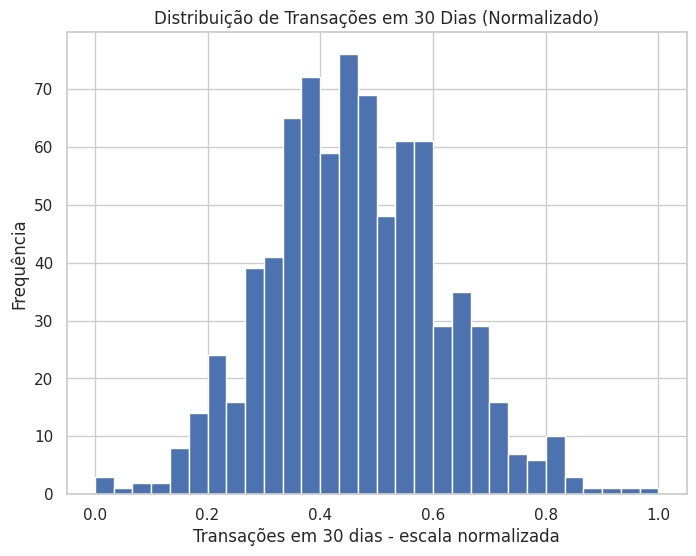

In [27]:
plt.figure(figsize=(8, 6))
plt.hist(df_normalized["transacoes_30d"].dropna(), bins=30)
plt.title("Distribuição de Transações em 30 Dias (Normalizado)")
plt.xlabel("Transações em 30 dias - escala normalizada")
plt.ylabel("Frequência")
plt.show()


Após a normalização, os atributos numéricos passam a compartilhar uma mesma escala, preservando a forma geral da distribuição. Essa etapa é útil principalmente quando diferentes variáveis possuem ordens de grandeza muito distintas, como volume de transações e taxa de erro.


## Padronização

A padronização por **Z-score** transforma as variáveis numéricas para média aproximadamente zero e desvio padrão aproximadamente um. Essa abordagem é particularmente útil quando a etapa futura exigir comparação de desvios relativos entre atributos.


In [28]:
# Pipeline de transformação numérica com imputação e padronização
pipeline_padronizacao = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler())
])

X_padronizado = pd.DataFrame(
    pipeline_padronizacao.fit_transform(X[colunas_numericas]),
    columns=colunas_numericas,
    index=X.index
)


In [29]:
# Visualização da base numérica padronizada
X_padronizado.head()


,id_cliente,tempo_base_meses,transacoes_30d,valor_total_30d,dias_desde_ultima_transacao,taxa_erro_30d,qtd_falhas_30d,percentual_pix_noturno,concentracao_top_dia,ticket_medio_30d
0,-1.7299,-1.7067,1.6816,-1.4316,0.3331,-0.2244,2.4882,0.1070,-0.4445,-1.4450
1,-1.7256,0.2505,0.5419,-0.0987,-1.5379,0.9200,1.9928,0.1459,0.2271,-0.1633
2,-1.7212,0.8305,-0.8257,-1.0248,0.5599,-0.4698,-0.4843,-0.9813,-0.6658,-0.9861
3,-1.7169,0.1781,2.8212,-0.1129,-0.1772,-0.3017,-0.4843,-0.7696,1.3427,-0.3735
4,-1.7126,-0.4019,-0.2179,-0.0916,-1.2544,0.9589,-0.9797,-0.2002,1.1751,-0.0749


In [30]:
df_standardized = X_padronizado.copy()
df_standardized.describe().T


,count,mean,std,min,25%,50%,75%,max
id_cliente,800.0000,0.0000,1.0006,-1.7299,-0.8649,0.0000,0.8649,1.7299
tempo_base_meses,800.0000,0.0000,1.0006,-1.7067,-0.9093,-0.0394,0.9030,1.7004
transacoes_30d,800.0000,-0.0000,1.0006,-3.0290,-0.6737,0.0101,0.6369,3.5050
valor_total_30d,800.0000,0.0000,1.0006,-1.5687,-0.7455,-0.1980,0.4478,5.6905
dias_desde_ultima_transacao,800.0000,0.0000,1.0006,-1.6513,-0.8576,-0.0638,0.9001,1.7505
taxa_erro_30d,800.0000,-0.0000,1.0006,-1.4296,-0.7003,-0.2244,0.5151,5.1739
qtd_falhas_30d,800.0000,0.0000,1.0006,-1.9705,-0.4843,0.0111,0.5066,3.9744
percentual_pix_noturno,800.0000,0.0000,1.0006,-1.7861,-0.7656,-0.0834,0.5855,3.8527
concentracao_top_dia,800.0000,0.0000,1.0006,-2.4286,-0.7152,-0.0435,0.7539,2.4343
ticket_medio_30d,800.0000,0.0000,1.0006,-1.5625,-0.7036,-0.1884,0.4356,5.6606


In [31]:
print("\nPrimeiras 5 linhas dos dados padronizados:")
print(df_standardized.head())



Primeiras 5 linhas dos dados padronizados:
   id_cliente  tempo_base_meses  transacoes_30d  valor_total_30d  \
0     -1.7299           -1.7067          1.6816          -1.4316   
1     -1.7256            0.2505          0.5419          -0.0987   
2     -1.7212            0.8305         -0.8257          -1.0248   
3     -1.7169            0.1781          2.8212          -0.1129   
4     -1.7126           -0.4019         -0.2179          -0.0916   

   dias_desde_ultima_transacao  taxa_erro_30d  qtd_falhas_30d  \
0                       0.3331        -0.2244          2.4882   
1                      -1.5379         0.9200          1.9928   
2                       0.5599        -0.4698         -0.4843   
3                      -0.1772        -0.3017         -0.4843   
4                      -1.2544         0.9589         -0.9797   

   percentual_pix_noturno  concentracao_top_dia  ticket_medio_30d  
0                  0.1070               -0.4445           -1.4450  
1                  0

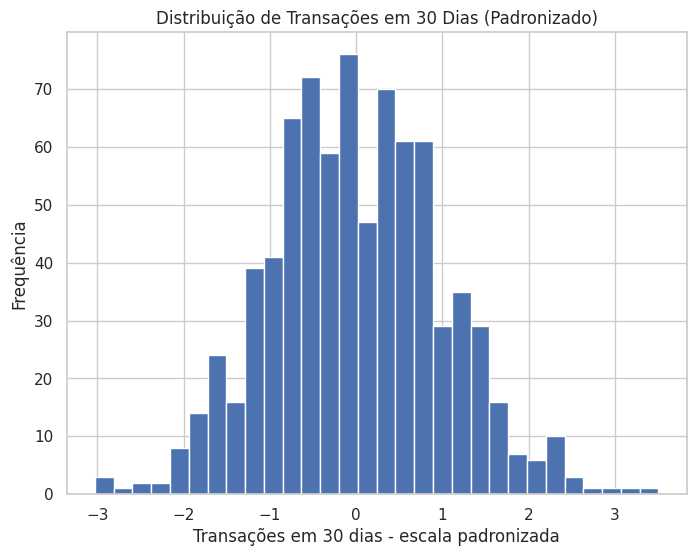

In [32]:
plt.figure(figsize=(8, 6))
plt.hist(df_standardized["transacoes_30d"].dropna(), bins=30)
plt.title("Distribuição de Transações em 30 Dias (Padronizado)")
plt.xlabel("Transações em 30 dias - escala padronizada")
plt.ylabel("Frequência")
plt.show()


Após a padronização, a distribuição fica centrada e expressa em desvios em relação à média. Isso não elimina assimetria ou outliers, mas facilita o tratamento posterior quando métodos analíticos dependem de variáveis em escalas comparáveis.


## Outras Transformações e Etapas de Pré-Processamento

Com base na análise exploratória realizada, um pipeline recomendado para esta base seria composto pelas seguintes etapas:

1. **Padronização dos nomes das colunas** e revisão de tipos;
2. **Remoção de identificadores** sem valor preditivo direto, como `id_cliente`, quando necessário em etapa futura de modelagem;
3. **Tratamento de valores nulos**, com mediana para campos numéricos e moda para categóricos;
4. **Codificação de variáveis categóricas**, como segmento, UF, status e indicador de webhook;
5. **Escalonamento das variáveis numéricas**, escolhendo normalização ou padronização conforme a técnica posterior;
6. **Monitoramento de outliers**, especialmente em valor transacionado, ticket médio e transações;
7. **Documentação das regras de negócio**, para manter rastreabilidade e consistência analítica.

A célula abaixo implementa um pipeline de pré-processamento completo e reprodutível, sem aplicar modelo de Machine Learning.


# Respondendo nossas hipóteses

As hipóteses levantadas no início do notebook podem ser respondidas com base nas tabelas e visualizações produzidas na análise exploratória. As células seguintes consolidam essas respostas em linguagem de negócio, conectando distribuição, comparação entre grupos e qualidade operacional.


## Hipótese 1


In [33]:
# Hipótese 1:
# Clientes com menor volume de transações e menor recorrência de uso apresentam maior propensão ao churn.

hipotese_1 = (
    df.groupby("churn")[["transacoes_30d", "dias_desde_ultima_transacao", "valor_total_30d"]]
      .mean()
      .rename(index={0: "nao_churn", 1: "churn"})
)

hipotese_1


,transacoes_30d,dias_desde_ultima_transacao,valor_total_30d
churn,,,
nao_churn,180.8218,24.4851,"20,938.2345"
churn,178.8939,33.8586,"21,866.9322"


## Hipótese 2


In [34]:
# Hipótese 2:
# Clientes com maior taxa de erro e maior volume de falhas tendem a apresentar mais churn.

hipotese_2 = (
    df.groupby("churn")[["taxa_erro_30d", "qtd_falhas_30d"]]
      .mean()
      .rename(index={0: "nao_churn", 1: "churn"})
)

hipotese_2


,taxa_erro_30d,qtd_falhas_30d
churn,,
nao_churn,0.0658,3.6980
churn,0.1013,4.2626


## Hipótese 3


In [35]:
# Hipótese 3:
# Clientes com menor maturidade de relacionamento e menor adoção de recursos tendem a apresentar maior risco de churn.

pipeline_preprocessamento = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputacao", SimpleImputer(strategy="median")),
            ("padronizacao", StandardScaler())
        ]), colunas_numericas),
        ("cat", Pipeline(steps=[
            ("imputacao", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas),
    ],
    remainder="drop"
)

X_preprocessado = pipeline_preprocessamento.fit_transform(X)

print("Shape após pré-processamento:", X_preprocessado.shape)

hipotese_3 = {
    "tempo_medio_por_churn": df.groupby("churn")["tempo_base_meses"].mean().to_dict(),
    "uso_webhook_por_churn": pd.crosstab(df["possui_webhook"], df["churn"], normalize="columns")
}

hipotese_3


Shape após pré-processamento: (800, 29)


{'tempo_medio_por_churn': {0: 25.831683168316832, 1: 23.22979797979798},
 'uso_webhook_por_churn': churn               0      1
 possui_webhook              
 nao            0.3490 0.4722
 sim            0.6510 0.5278}

# Conclusão

A revisão deste notebook mostrou que a análise de churn em clientes da **API PIX** depende fortemente da leitura conjunta entre **uso transacional, recorrência, estabilidade operacional e maturidade do relacionamento**. Mesmo sem avançar para a etapa de modelagem, a EDA já permite identificar sinais importantes de risco.

De forma geral, os atributos mais promissores para o problema são:

- volume e valor transacionado no período;
- dias desde a última transação;
- taxa de erro e quantidade de falhas;
- tempo de relacionamento;
- uso de recursos complementares, como webhook;
- status operacional/comercial do cliente.

Além disso, o notebook passou a contar com:

- comentários padronizados e mais aderentes ao negócio;
- correção de células incompletas ou inconsistentes;
- centralização das bibliotecas em uma única célula;
- tratamento estruturado de nulos;
- proposta de pipeline de pré-processamento reprodutível e sem uso de modelo de Machine Learning.

Como próximo passo natural, a base já fica preparada para uma futura etapa de engenharia de atributos, validação de qualidade e construção de modelos preditivos de churn em ambiente controlado.
